Outlier detection and removal using z-score and standard deviation in python pandas

In [3]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10,6)

In [4]:
df = pd.read_csv("heightsss.csv")
df.sample(5)

,gender,height
2304,Male,63.472414
6783,Female,62.490958
3606,Male,65.220379
5548,Female,64.366194
7568,Female,65.363737


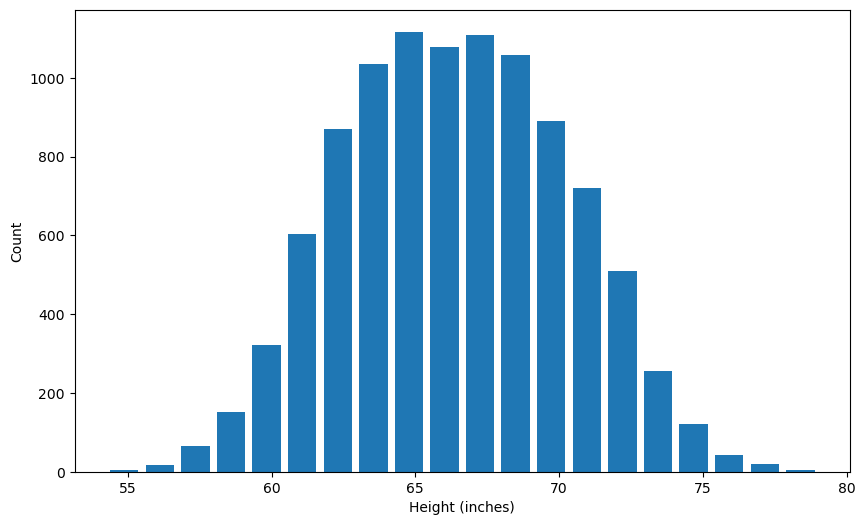

In [5]:
plt.hist(df.height, bins=20, rwidth=0.8)
plt.xlabel('Height (inches)')
plt.ylabel('Count')
plt.show()

Plot bell curve along with histogram for our dataset

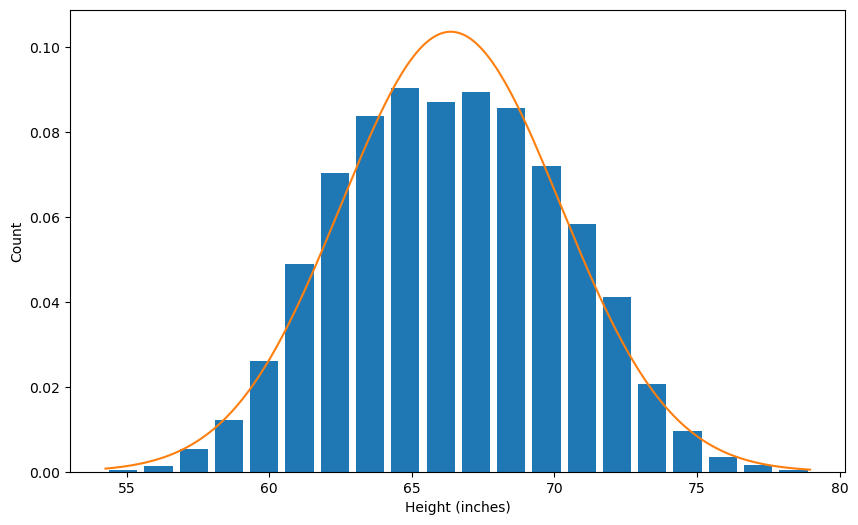

In [6]:
from scipy.stats import norm
import numpy as np
plt.hist(df.height, bins=20, rwidth=0.8, density=True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(df.height.min(), df.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.height.mean(), df.height.std()))

In [7]:
df.height.mean()

66.367559754866

In [8]:
df.height.std()

3.847528120795573

(1) Outlier detection and removal using 3 standard deviation

In [10]:
upper_limit = df.height.mean() + ( 3 * df.height.std() ) 
upper_limit

77.91014411725271

In [12]:
lower_limit = df.height.mean() - ( 3 * df.height.std() )
lower_limit

54.824975392479274

In [13]:
df[(df.height > upper_limit) | (df.height < lower_limit)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


Now remove these outliers and generate new dataframe

In [15]:
df_no_outlier_std_dev = df[(df.height < upper_limit) & (df.height > lower_limit)]
df_no_outlier_std_dev.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [16]:
df_no_outlier_std_dev.shape

(9993, 2)

In [17]:
df.shape

(10000, 2)

(2) Outlier detection and removal using Z Score

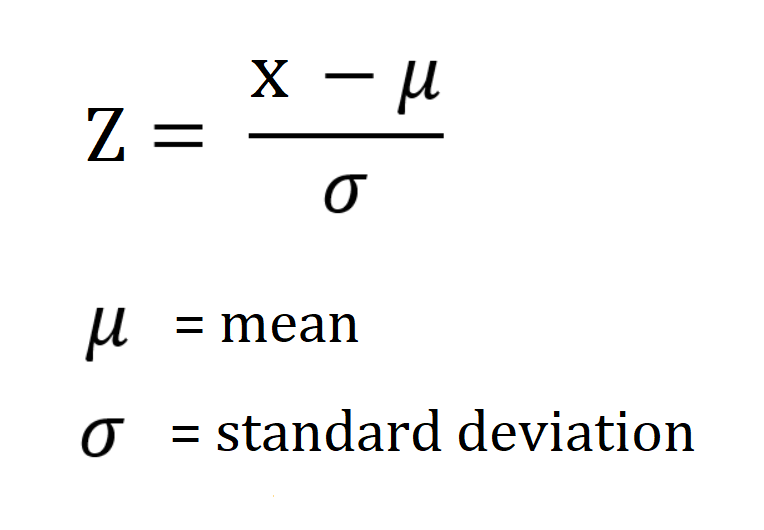

In [19]:
df['zscore'] = ( df.height - df.height.mean() ) / df.height.std()
df.head(5)

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [20]:
(73.84 - 66.37) / 3.84

1.9453124999999998

Get data points that has z score higher than 3 or lower than -3. Another way of saying same thing is get data points that are more than 3 standard deviation away

In [21]:
df[df['zscore'] > 3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [22]:
df[df['zscore'] < -3]

,gender,height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [23]:
# Here is the list of all outliers
df[(df.zscore < -3) | (df.zscore > 3)]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


Remove the outliers and produce new dataframe

In [24]:
df_no_outliers = df[(df.zscore > -3) & (df.zscore < 3)]
df_no_outliers.head()

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [25]:
df_no_outliers.shape

(9993, 3)

In [26]:
df.shape

(10000, 3)